# Erdos Institute Summer 2026 Project
## Sustainability of US cities

This project attempts to answer the following:

&#9989; **<font color=blue>QUESTION:** <font color=blue> In which county should someone aim to live in, for the next 20 years? 

We will try to determine which U.S. counties/cities are the most environmentally, economically, and socially sustainable using sustainability metrics from the [United Nations Sustainable Development Goals](https://sdgs.un.org/goals). 

---
This notebook will show some exploratory data analysis along the theme of air pollution and climate risk, as follows:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

#### 1. Air pollution

This is from the EPA dataset, using the following 6  variables:
-  *RSEI_AIR*:	Toxic Releases to Air
-  *PTRAF*:	Traffic
-  *DSLPM*:	Diesel particulate matter
-  *OZONE*:	Ozone
-  *PM25*:	Particulate Matter 2.5
-  *NO2*: Nitrogen
    

In [3]:
epa_data = pd.read_csv("../data/EPA_EJSCREEN/epa_2024.csv", usecols=[1,2,3,4,6,32,33,34,35,36,44])

In [4]:
epa_data.sample(5)

,ID,STATE_NAME,ST_ABBREV,CNTY_NAME,ACSTOTPOP,PM25,OZONE,DSLPM,RSEI_AIR,PTRAF,NO2
2806,4015953200,ARIZONA,AZ,Mohave County,2813.0,5.744547,59.85867,0.089976,0.000000,2.991999e+05,9.704800
83657,55083101000,WISCONSIN,WI,Oconto County,4120.0,6.904262,61.91852,0.061593,336.006544,9.761255e+04,5.132353
62615,41017001102,OREGON,OR,Deschutes County,6466.0,14.611945,57.25767,0.085765,0.177004,6.233821e+05,7.077518
59232,39049008710,OHIO,OH,Franklin County,2164.0,8.236057,61.53496,0.291488,59874.921577,2.896809e+06,12.521621
76852,48463950202,TEXAS,TX,Uvalde County,5606.0,7.813893,61.09081,0.040648,0.001215,7.109770e+04,6.803862


In [5]:
# Truncate dataset to get rid of US territories Puerto Rico, Virgin Islands, etc, that have missing entries
epa_data=epa_data.iloc[0:84415]

In [6]:
epa_data.isna().sum()

ID              0
STATE_NAME      0
ST_ABBREV       0
CNTY_NAME       0
ACSTOTPOP       1
PM25          639
OZONE         639
DSLPM         744
RSEI_AIR      320
PTRAF         568
NO2           299
dtype: int64

In [7]:
# columns of interest
cols = ["DSLPM", "ACSTOTPOP", "PM25", "RSEI_AIR", "PTRAF", "NO2", "OZONE"]
ids=[ "ID", "CNTY_NAME", "STATE_NAME", "ST_ABBREV"]
all_cols=["ID", "CNTY_NAME", "STATE_NAME", "ST_ABBREV", "DSLPM", "ACSTOTPOP", "PM25", "RSEI_AIR", "PTRAF", "NO2", "OZONE"]

In [8]:
# More data wrangling:
epa_data["ID"] = epa_data["ID"].astype(str).str.zfill(11)
epa_data["county_fips"] = epa_data["ID"].str[:5]

The next few cells will group by 'county_fips' and sum numeric columns, while keeping one representative value for other columns. Note that this is different than grouping by "CNTY_NAME" because there are counties with similar names in different states.


In [9]:
geo_lookup = epa_data[["county_fips", "STATE_NAME", "CNTY_NAME"]].drop_duplicates()

In [10]:
epa_county= (
    epa_data
    .groupby("county_fips")[cols]
    .sum()
    .reset_index()
)



In [11]:
epa_county = epa_county.merge(geo_lookup, on="county_fips", how="left")
epa_county.sample(5)

,county_fips,DSLPM,ACSTOTPOP,PM25,RSEI_AIR,PTRAF,NO2,OZONE,STATE_NAME,CNTY_NAME
2840,51036,0.225794,6760.0,19.592807,18587.515701,1.149429e+05,8.377907,157.464880,VIRGINIA,Charles City County
949,20119,0.096110,4019.0,13.157221,55.942890,8.556630e+04,10.568452,111.679352,KANSAS,Meade County
677,17161,5.795119,143819.0,369.352727,70950.209661,6.242296e+07,368.018406,2633.758940,ILLINOIS,Rock Island County
2752,48455,0.289982,13735.0,41.001552,26.295519,8.252173e+03,20.976201,305.504950,TEXAS,Trinity County
549,15003,47.231624,1010100.0,0.000000,215310.608511,9.910735e+08,1964.729502,0.000000,HAWAII,Honolulu County


In [12]:
len(epa_county)

3144

In [13]:
epa_county.isna().sum()

county_fips    0
DSLPM          0
ACSTOTPOP      0
PM25           0
RSEI_AIR       0
PTRAF          0
NO2            0
OZONE          0
STATE_NAME     0
CNTY_NAME      0
dtype: int64

In [14]:
epa_county["county_fips"] = epa_county["county_fips"].astype(str).str.zfill(5)
epa_county.head(5)

,county_fips,DSLPM,ACSTOTPOP,PM25,RSEI_AIR,PTRAF,NO2,OZONE,STATE_NAME,CNTY_NAME
0,01001,1.651933,58761.0,151.485051,27855.216606,5.132866e+06,86.592439,861.26294,ALABAMA,Autauga County
1,01003,3.358812,233420.0,401.139383,20079.286568,8.745981e+06,159.683913,2420.76095,ALABAMA,Baldwin County
2,01005,0.422200,24877.0,75.294504,1236.330165,8.452157e+05,33.384179,471.28931,ALABAMA,Barbour County
3,01007,0.472859,22251.0,68.455260,16008.211721,3.621324e+05,20.233755,417.27886,ALABAMA,Bibb County
4,01009,1.214561,59077.0,135.804857,23375.038137,8.701433e+05,52.888764,880.67126,ALABAMA,Blount County


In [16]:
epa_county.to_csv("../data/epa_county.csv")

---
#### 2. Learn about the data

array([[<Axes: title={'center': 'DSLPM'}>,
        <Axes: title={'center': 'ACSTOTPOP'}>,
        <Axes: title={'center': 'PM25'}>],
       [<Axes: title={'center': 'RSEI_AIR'}>,
        <Axes: title={'center': 'PTRAF'}>,
        <Axes: title={'center': 'NO2'}>],
       [<Axes: title={'center': 'OZONE'}>, <Axes: >, <Axes: >]],
      dtype=object)

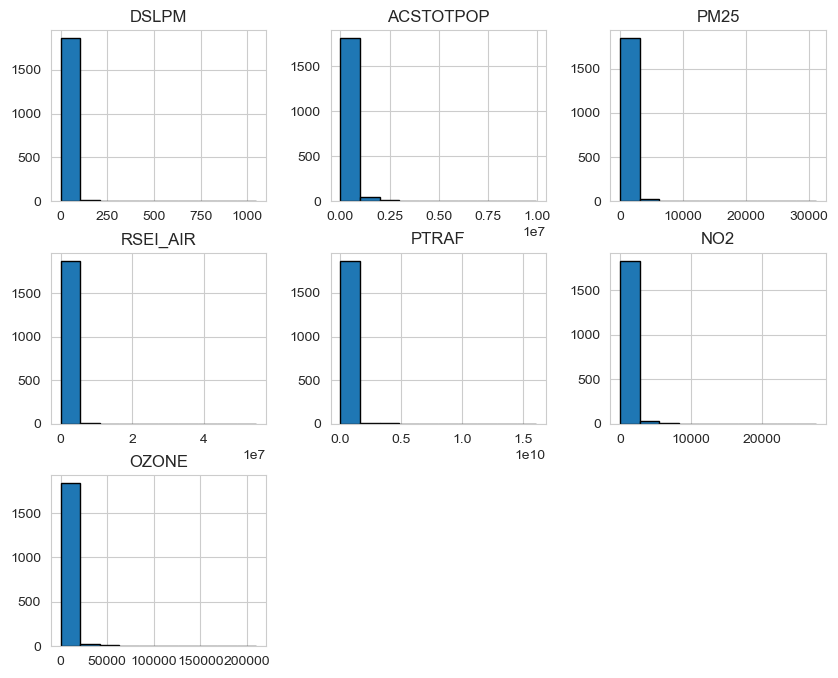

In [19]:
epa_county[cols].hist(figsize=(10, 8), bins=10, edgecolor='black')

In [20]:
epa_county[cols].describe()

,DSLPM,ACSTOTPOP,PM25,RSEI_AIR,PTRAF,NO2,OZONE
count,1882.000000,1.882000e+03,1882.000000,1.882000e+03,1.882000e+03,1882.000000,1882.000000
mean,8.546708,1.759286e+05,376.071451,2.098525e+05,7.535925e+07,348.459251,2754.837199
std,38.953246,4.796827e+05,1174.662493,1.569277e+06,4.977554e+08,1226.024757,8315.356935
min,0.000000,5.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.094388,0.000000
25%,0.228135,1.384350e+04,29.481857,1.396434e+02,1.250322e+05,19.310845,249.879077
50%,0.752460,3.892000e+04,78.032492,2.465563e+03,1.052331e+06,51.487426,619.670530
75%,3.400872,1.288485e+05,250.429297,3.228717e+04,1.065529e+07,182.666120,1974.687752
max,1047.466894,9.936690e+06,31126.530753,5.456255e+07,1.606902e+10,27563.740922,209964.315887


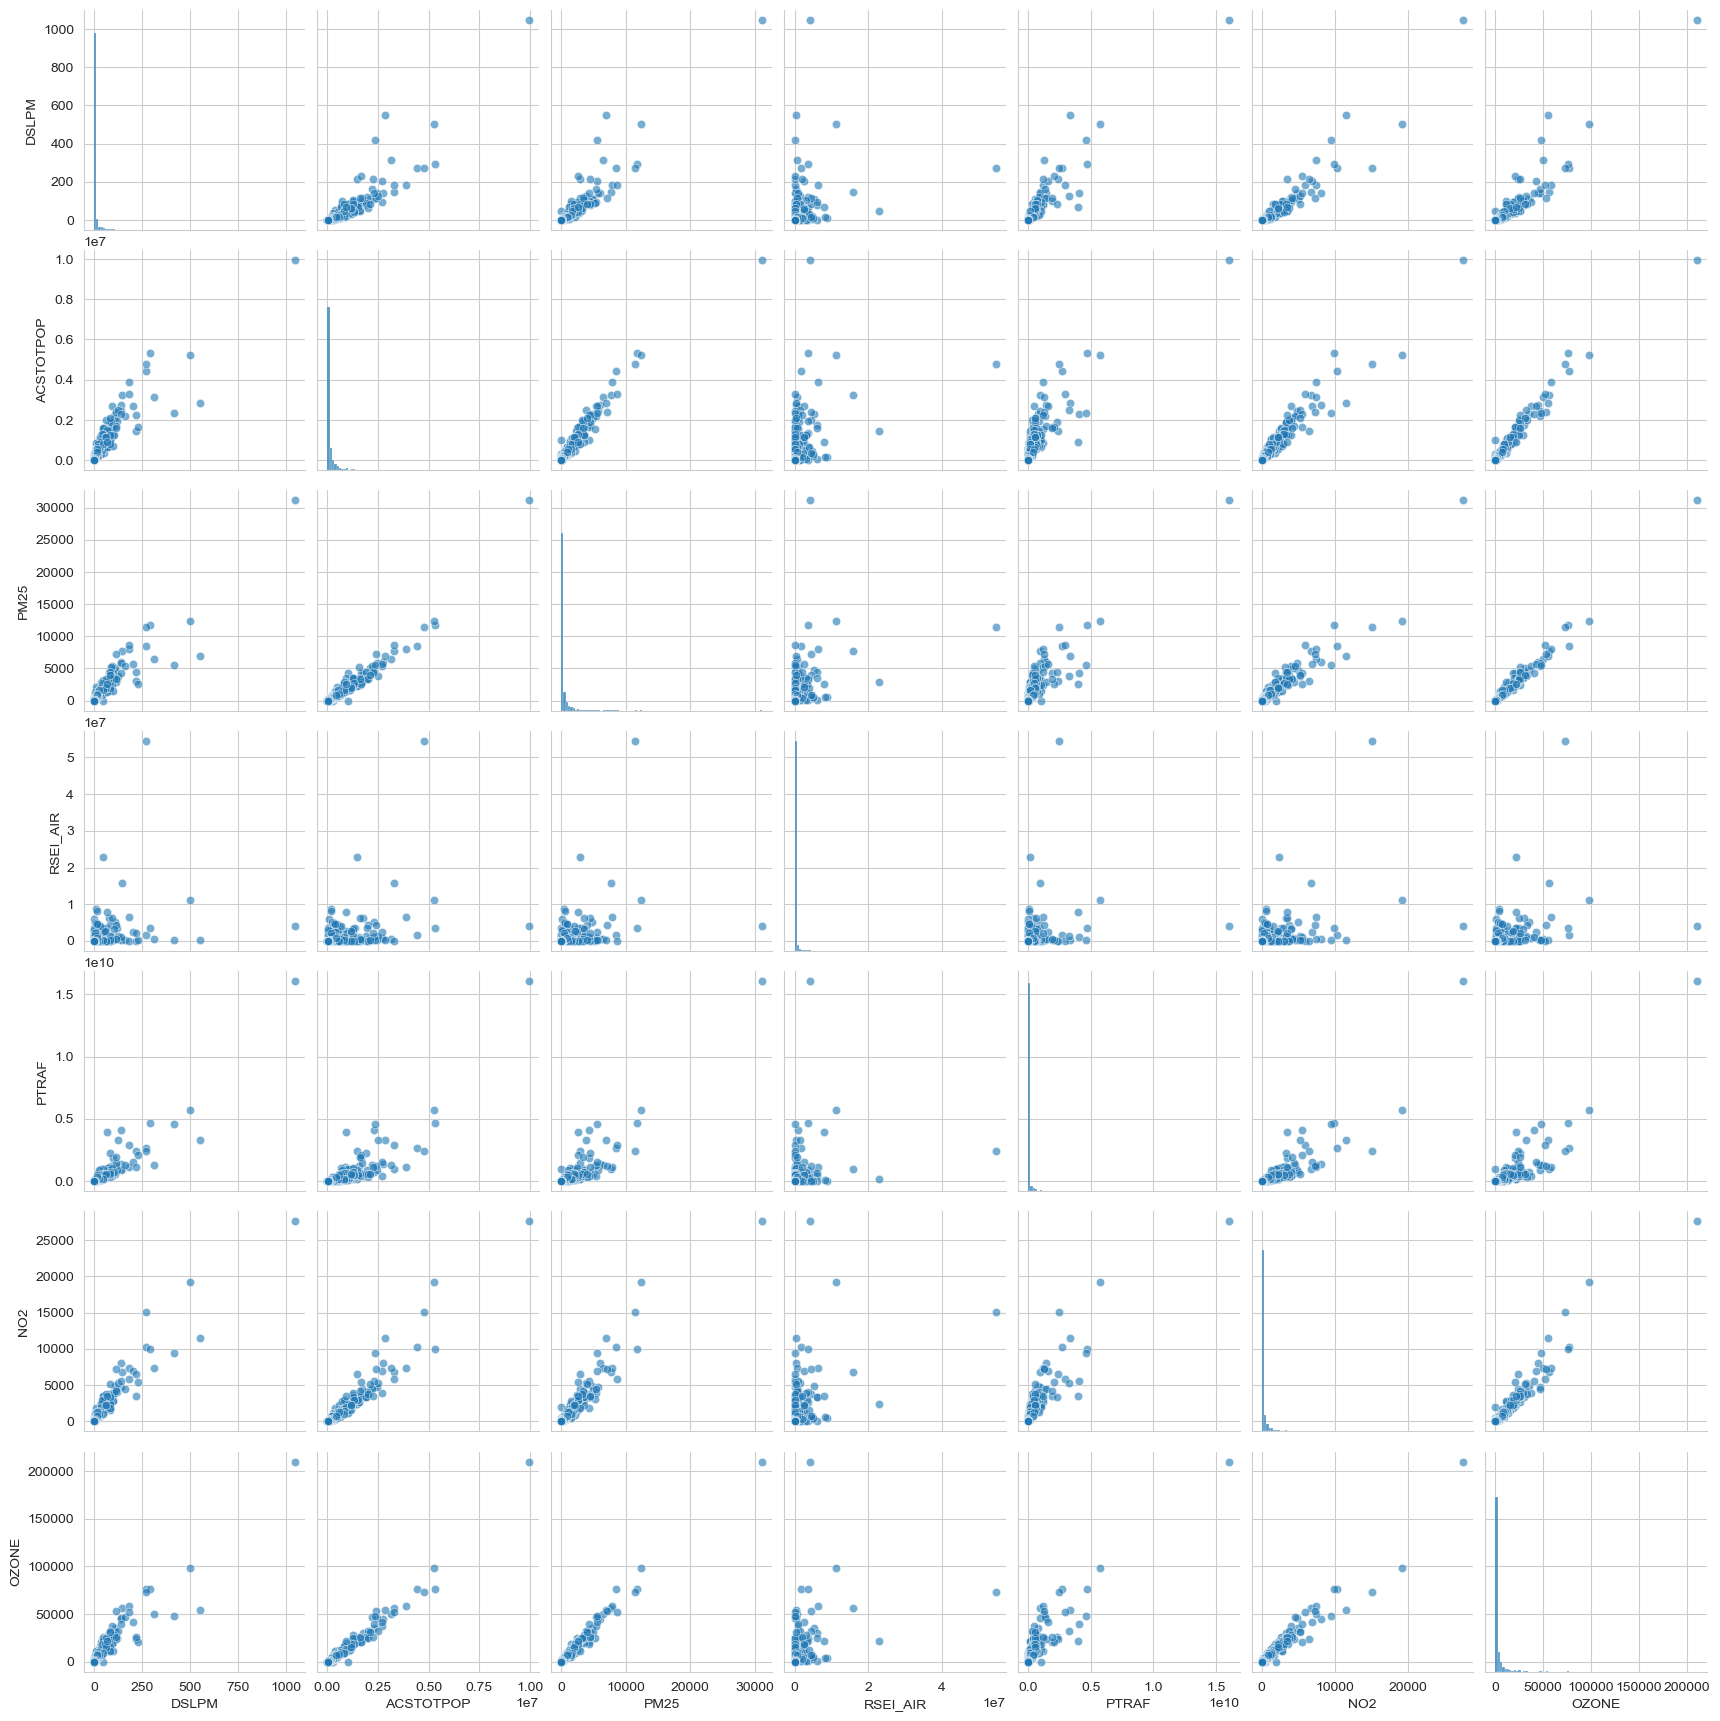

In [39]:
sns.pairplot(data = epa_county[cols],
                x_vars = cols,
                y_vars = cols,
                plot_kws = {'alpha':.6})

plt.show()

There appear to be several co-linear relationships between the variables. 

---
#### 2. Climate and natural hazard risk 

This is from the National risk index dataset, using the variables:

- *RISK_SCORE*: National Risk Index - Score - Composite
- *EAL_SCORE*: 	Expected Annual Loss - Score - Composite
- *SOVI_SCORE*:	Social Vulnerability - Score
- *RESL_SCORE*:	Community Resilience - Score
  

In [17]:
nri_data = pd.read_csv("../data/NRI_Table_Counties/NRI_Table_Counties.csv")

columns=["STATE", "COUNTY", "STCOFIPS", "POPULATION", "AREA", "RISK_SCORE", "EAL_SCORE", "SOVI_SCORE", "RESL_SCORE"]
nri_data=nri_data[columns]

In [18]:
nri_data["STCOFIPS"] = nri_data["STCOFIPS"].astype(str).str.zfill(5)

nri_data.sample(5)

,STATE,COUNTY,STCOFIPS,POPULATION,AREA,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE
2420,South Dakota,Ziebach,46137,2413,1990.490048,25.190840,10.952970,99.745547,0.381679
1964,North Carolina,Sampson,37163,59021,957.399442,90.203562,85.055693,88.326972,9.446565
451,Georgia,Harris,13145,34598,477.731163,20.769720,28.372525,23.791349,52.385496
2912,Virginia,Chesapeake,51550,249270,354.489629,80.852417,85.396040,13.772265,89.694656
1063,Kentucky,Marion,21155,19521,350.358658,30.216285,30.878713,51.622137,61.577608


In [19]:
nri_data.isna().sum()

STATE          0
COUNTY         0
STCOFIPS       0
POPULATION     0
AREA           0
RISK_SCORE    88
EAL_SCORE      0
SOVI_SCORE    88
RESL_SCORE    88
dtype: int64

In [21]:
nri_data.dropna()
nri_data

,STATE,COUNTY,STCOFIPS,POPULATION,AREA,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE
0,Alabama,Autauga,01001,58764,610.470508,57.569975,59.870050,38.040712,55.120865
1,Alabama,Baldwin,01003,231365,2047.738775,96.723919,96.627475,44.243003,93.002545
2,Alabama,Barbour,01005,25160,913.646511,48.123410,30.538366,96.374046,11.164122
3,Alabama,Bibb,01007,22239,632.486798,39.122137,31.002475,75.254453,22.169211
4,Alabama,Blount,01009,58992,657.196555,68.479644,62.345297,69.338422,15.648855
...,...,...,...,...,...,...,...,...,...
3227,Connecticut,Northeastern Connecticut,09150,95308,568.841945,62.754453,75.247525,10.623410,61.800254
3228,Connecticut,Northwest Hills,09160,112433,816.266403,79.611959,84.684406,12.754453,76.685751
3229,Connecticut,South Central Connecticut,09170,570229,625.834253,95.133588,95.049505,45.197201,79.707379
3230,Connecticut,Southeastern Connecticut,09180,280316,688.594059,88.645038,89.263614,26.749364,86.386768


array([[<Axes: title={'center': 'STCOFIPS'}>,
        <Axes: title={'center': 'POPULATION'}>,
        <Axes: title={'center': 'AREA'}>],
       [<Axes: title={'center': 'RISK_SCORE'}>,
        <Axes: title={'center': 'EAL_SCORE'}>,
        <Axes: title={'center': 'SOVI_SCORE'}>],
       [<Axes: title={'center': 'RESL_SCORE'}>, <Axes: >, <Axes: >]],
      dtype=object)

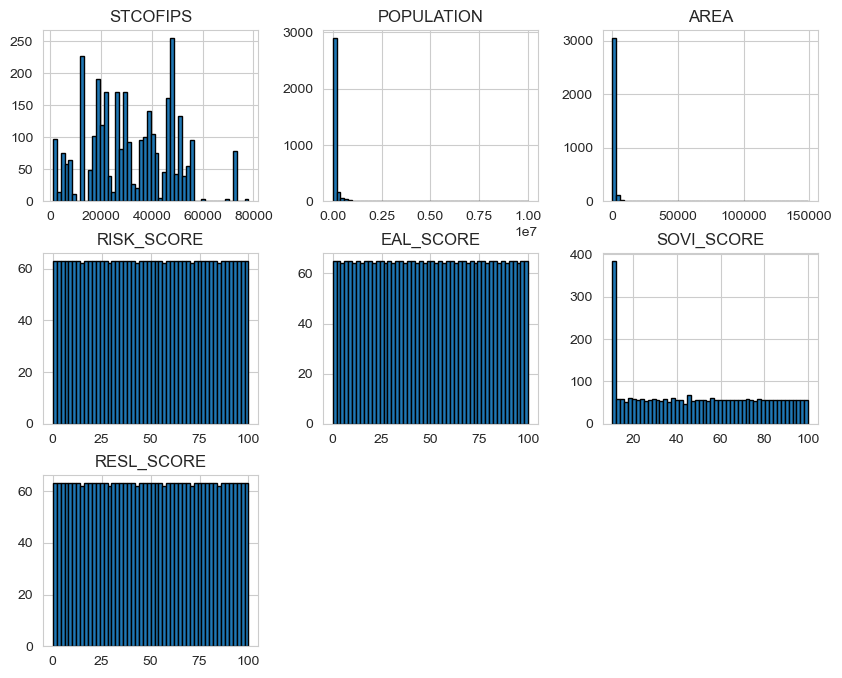

In [29]:
nri_data.hist(figsize=(10, 8), bins=50, edgecolor='black')

In [22]:
nri_data.to_csv("../data/nri_data.csv")

#### 3. Cancer and non-cancer risk data

In [23]:
## On non-cancer hazard risks:
non_can=pd.read_excel("../data/Food Environment/nata2014v2_national_allhi.xlsx")
non_can.head()


,Tract,Population,Respiratory HI,Neurological HI,Liver HI,Developmental HI,Reproductive HI,Kidney HI,Ocular HI,Endocrine HI,Hematological HI,Immunological HI,Skeletal HI,Spleen HI,Thyroid HI,Whole Body HI
0,0,312572412,0.436622,0.041939,0.014928,0.037268,0.051583,0.010736,8.439492e-06,0.000004,2.078270e-06,0.024822,0.000224,0.000106,0.008953,0.002224
1,1000000000,4779690,0.655975,0.035416,0.012497,0.052604,0.065680,0.007498,9.366032e-08,0.000004,3.349246e-07,0.019632,0.000155,0.000180,0.006015,0.000150
2,1001000000,54571,0.799127,0.038198,0.011782,0.062827,0.079101,0.005948,1.766050e-10,0.000002,2.333518e-07,0.017973,0.000056,0.000003,0.009789,0.000187
3,1001020100,1912,0.788052,0.037008,0.011426,0.061682,0.078886,0.005549,2.030090e-10,0.000002,2.896206e-07,0.016504,0.000075,0.000003,0.011047,0.000191
4,1001020200,2170,0.808744,0.043448,0.012986,0.064470,0.082523,0.006953,2.402750e-10,0.000002,3.139884e-07,0.019033,0.000067,0.000003,0.012949,0.000196


In [30]:
# Aggregate the tract-level dataset to the county level first,
# and then merge with other county-level datasets using the county FIPS code

non_can["Tract"] = non_can["Tract"].astype(str).str.zfill(11)
non_can["county_fips"] = non_can["Tract"].str[:5]

keep_cols=["Tract", "county_fips", "Population", "Whole Body HI"]
non_can=non_can[keep_cols]


non_cancer_risk = (
    non_can
    .groupby("county_fips", as_index=False)[["Population", "Whole Body HI"]]
    .sum()
)



In [31]:
non_cancer_risk["county_fips"]= non_cancer_risk["county_fips"].astype(str).str.zfill(5)
non_cancer_risk = non_cancer_risk[~non_cancer_risk["county_fips"].str.endswith("000", na=False)]

non_cancer_risk

,county_fips,Population,Whole Body HI
2,01001,109142,0.002406
3,01003,364530,0.003245
4,01005,54914,0.002081
5,01007,45830,0.000780
6,01009,114644,0.001453
...,...,...,...
3271,72151,75882,0.001665
3272,72153,84086,0.002213
3274,78010,101202,0.000005
3275,78020,8340,0.000001


In [32]:
non_cancer_risk.to_csv("../data/non_cancer_risk.csv")

In [24]:
# On cancer risk:
cancer_risk=pd.read_excel("../data/Food Environment/nata2014v2_national_cancerrisk_by_tract_srcgrp.xlsx")

keep=["State", "FIPS", "County", "Population", "Total Cancer Risk (per million)"]
cancer_risk = cancer_risk[keep] 

cancer_risk["FIPS"] = cancer_risk["FIPS"].astype(str).str.zfill(5)

cancer_risk

,State,FIPS,County,Population,Total Cancer Risk (per million)
0,US,00000,Entire US,312572412,31.689004
1,AL,01000,Entire State,4779690,43.314142
2,AL,01001,Autauga,54571,49.511426
3,AL,01001,Autauga,1912,49.377032
4,AL,01001,Autauga,2170,50.320741
...,...,...,...,...,...
76722,VI,78030,St. Thomas,4088,14.181113
76723,VI,78030,St. Thomas,4878,10.419422
76724,VI,78030,St. Thomas,5220,12.686213
76725,VI,78030,St. Thomas,4356,11.224384


Compress data to one entry per county:

In [25]:
geo_lookup_2 = cancer_risk[["FIPS", "State", "County"]].drop_duplicates()

In [26]:
cancer_risk_data= (
    cancer_risk
    .groupby("FIPS")[["Population", "Total Cancer Risk (per million)"]]
    .sum()
    .reset_index()
)
cancer_risk_data["FIPS"] = cancer_risk_data["FIPS"].astype(str).str.zfill(5)


In [27]:
cancer_risk_data = cancer_risk_data.merge(geo_lookup_2, on="FIPS", how="left")

cancer_risk_data

,FIPS,Population,Total Cancer Risk (per million),State,County
0,00000,312572412,31.689004,US,Entire US
1,01000,4779690,43.314142,AL,Entire State
2,01001,109142,641.344644,AL,Autauga
3,01003,364530,1131.580093,AL,Baldwin
4,01005,54914,457.387006,AL,Barbour
...,...,...,...,...,...
3272,72153,84086,204.795316,PR,Yauco
3273,78000,106405,10.693877,VI,Entire State
3274,78010,101202,158.828209,VI,St. Croix
3275,78020,8340,27.193711,VI,St. John


In [28]:
# Remove entries corresponding to "entire US" or "entire state"

cancer_risk_data = cancer_risk_data[~cancer_risk_data["FIPS"].str.endswith("000", na=False)]
cancer_risk_data

,FIPS,Population,Total Cancer Risk (per million),State,County
2,01001,109142,641.344644,AL,Autauga
3,01003,364530,1131.580093,AL,Baldwin
4,01005,54914,457.387006,AL,Barbour
5,01007,45830,229.922349,AL,Bibb
6,01009,114644,391.032211,AL,Blount
...,...,...,...,...,...
3271,72151,75882,153.421453,PR,Yabucoa
3272,72153,84086,204.795316,PR,Yauco
3274,78010,101202,158.828209,VI,St. Croix
3275,78020,8340,27.193711,VI,St. John


In [29]:
cancer_risk_data.to_csv("../data/cancer_risk_data.csv")

#### 4. Merge datasets

In [33]:
master = pd.read_csv("../data/identifiers/master.csv")

In [35]:
master["FIPS"] = master["FIPS"].astype(str).str.zfill(5)
epa_county["county_fips"] = epa_county["county_fips"].astype(str).str.zfill(5)

In [36]:
# Begin merging
# First merge EPA data
master_1 = master.merge(
 epa_county,
   left_on="FIPS",
   right_on="county_fips",
   how="left"
)

In [37]:
master_1 = master_1.drop(columns=["STATE_NAME", "CNTY_NAME"])

In [65]:
# master = master.loc[:, ~master.columns.str.endswith("_y")]

In [38]:
master_1

,Unnamed: 0,state,county,state_code,FIPS,county_fips,DSLPM,ACSTOTPOP,PM25,RSEI_AIR,PTRAF,NO2,OZONE
0,0,ALABAMA,AUTAUGA,AL,01001,01001,1.651933,58761.0,151.485051,27855.216606,5.132866e+06,86.592439,861.26294
1,6,ALABAMA,BALDWIN,AL,01003,01003,3.358812,233420.0,401.139383,20079.286568,8.745981e+06,159.683913,2420.76095
2,30,ALABAMA,BARBOUR,AL,01005,01005,0.422200,24877.0,75.294504,1236.330165,8.452157e+05,33.384179,471.28931
3,38,ALABAMA,BIBB,AL,01007,01007,0.472859,22251.0,68.455260,16008.211721,3.621324e+05,20.233755,417.27886
4,47,ALABAMA,BLOUNT,AL,01009,01009,1.214561,59077.0,135.804857,23375.038137,8.701433e+05,52.888764,880.67126
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,40370,WYOMING,SWEETWATER,WY,56037,56037,1.930004,42079.0,55.579054,1500.645361,3.169414e+06,101.980192,821.90771
3150,40388,WYOMING,TETON,WY,56039,56039,0.209617,23346.0,31.094303,0.000000,7.029438e+05,35.287269,431.84169
3151,40396,WYOMING,UINTA,WY,56041,56041,0.565113,20546.0,32.858091,65.787018,8.462275e+05,52.263287,396.38884
3152,40403,WYOMING,WASHAKIE,WY,56043,56043,0.095968,7725.0,13.758103,646.642619,2.140387e+05,22.789069,181.04902


In [39]:
# Check which counties did not get matched to EPA data:
missing_counties = set(master_1["FIPS"]) - set(epa_county["county_fips"])
print(len(missing_counties))
print(list(missing_counties)[:10])

20
['09011', '09001', '09005', '51560', '09015', '09009', '02280', '00000', '02261', '02201']


In [40]:
# Continue merging,
# With NRI data
master_2= master_1.merge(
   nri_data,
   left_on="FIPS",
   right_on="STCOFIPS", 
     how="left"
 )

In [41]:
master_2

,Unnamed: 0,state,county,state_code,FIPS,county_fips,DSLPM,ACSTOTPOP,PM25,RSEI_AIR,...,OZONE,STATE,COUNTY,STCOFIPS,POPULATION,AREA,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE
0,0,ALABAMA,AUTAUGA,AL,01001,01001,1.651933,58761.0,151.485051,27855.216606,...,861.26294,Alabama,Autauga,01001,58764.0,610.470508,57.569975,59.870050,38.040712,55.120865
1,6,ALABAMA,BALDWIN,AL,01003,01003,3.358812,233420.0,401.139383,20079.286568,...,2420.76095,Alabama,Baldwin,01003,231365.0,2047.738775,96.723919,96.627475,44.243003,93.002545
2,30,ALABAMA,BARBOUR,AL,01005,01005,0.422200,24877.0,75.294504,1236.330165,...,471.28931,Alabama,Barbour,01005,25160.0,913.646511,48.123410,30.538366,96.374046,11.164122
3,38,ALABAMA,BIBB,AL,01007,01007,0.472859,22251.0,68.455260,16008.211721,...,417.27886,Alabama,Bibb,01007,22239.0,632.486798,39.122137,31.002475,75.254453,22.169211
4,47,ALABAMA,BLOUNT,AL,01009,01009,1.214561,59077.0,135.804857,23375.038137,...,880.67126,Alabama,Blount,01009,58992.0,657.196555,68.479644,62.345297,69.338422,15.648855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,40370,WYOMING,SWEETWATER,WY,56037,56037,1.930004,42079.0,55.579054,1500.645361,...,821.90771,Wyoming,Sweetwater,56037,42238.0,10597.073996,30.629771,40.841584,19.338422,16.380407
3150,40388,WYOMING,TETON,WY,56039,56039,0.209617,23346.0,31.094303,0.000000,...,431.84169,Wyoming,Teton,56039,23250.0,4259.833177,70.642494,79.919554,10.623410,42.461832
3151,40396,WYOMING,UINTA,WY,56041,56041,0.565113,20546.0,32.858091,65.787018,...,396.38884,Wyoming,Uinta,56041,20412.0,2109.220457,16.698473,26.206683,14.949109,12.531807
3152,40403,WYOMING,WASHAKIE,WY,56043,56043,0.095968,7725.0,13.758103,646.642619,...,181.04902,Wyoming,Washakie,56043,7662.0,2265.341661,24.363868,17.914604,79.452926,55.375318


In [42]:
master_2 = master_2.drop(columns=["STATE", "COUNTY", "STCOFIPS", "ACSTOTPOP"])
master_2

,Unnamed: 0,state,county,state_code,FIPS,county_fips,DSLPM,PM25,RSEI_AIR,PTRAF,NO2,OZONE,POPULATION,AREA,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE
0,0,ALABAMA,AUTAUGA,AL,01001,01001,1.651933,151.485051,27855.216606,5.132866e+06,86.592439,861.26294,58764.0,610.470508,57.569975,59.870050,38.040712,55.120865
1,6,ALABAMA,BALDWIN,AL,01003,01003,3.358812,401.139383,20079.286568,8.745981e+06,159.683913,2420.76095,231365.0,2047.738775,96.723919,96.627475,44.243003,93.002545
2,30,ALABAMA,BARBOUR,AL,01005,01005,0.422200,75.294504,1236.330165,8.452157e+05,33.384179,471.28931,25160.0,913.646511,48.123410,30.538366,96.374046,11.164122
3,38,ALABAMA,BIBB,AL,01007,01007,0.472859,68.455260,16008.211721,3.621324e+05,20.233755,417.27886,22239.0,632.486798,39.122137,31.002475,75.254453,22.169211
4,47,ALABAMA,BLOUNT,AL,01009,01009,1.214561,135.804857,23375.038137,8.701433e+05,52.888764,880.67126,58992.0,657.196555,68.479644,62.345297,69.338422,15.648855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,40370,WYOMING,SWEETWATER,WY,56037,56037,1.930004,55.579054,1500.645361,3.169414e+06,101.980192,821.90771,42238.0,10597.073996,30.629771,40.841584,19.338422,16.380407
3150,40388,WYOMING,TETON,WY,56039,56039,0.209617,31.094303,0.000000,7.029438e+05,35.287269,431.84169,23250.0,4259.833177,70.642494,79.919554,10.623410,42.461832
3151,40396,WYOMING,UINTA,WY,56041,56041,0.565113,32.858091,65.787018,8.462275e+05,52.263287,396.38884,20412.0,2109.220457,16.698473,26.206683,14.949109,12.531807
3152,40403,WYOMING,WASHAKIE,WY,56043,56043,0.095968,13.758103,646.642619,2.140387e+05,22.789069,181.04902,7662.0,2265.341661,24.363868,17.914604,79.452926,55.375318


In [43]:
# Check which counties did not get matched to NRI data:
missing_counties = set(master_2["FIPS"]) - set(nri_data["STCOFIPS"])
print(len(missing_counties))
print(list(missing_counties)[:10])

20
['09011', '09001', '09005', '51560', '09015', '09009', '02280', '00000', '02261', '02201']


In [44]:
## Merge with cancer-risk data
master_3= master_2.merge(
   cancer_risk_data,
    left_on="FIPS",
     right_on="FIPS", 
    how="left"
 )

In [47]:
master_3=master_3.drop(columns=["State", "County", "county_fips", "POPULATION"])
master_3

,Unnamed: 0,state,county,state_code,FIPS,DSLPM,PM25,RSEI_AIR,PTRAF,NO2,OZONE,AREA,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE,Population,Total Cancer Risk (per million)
0,0,ALABAMA,AUTAUGA,AL,01001,1.651933,151.485051,27855.216606,5.132866e+06,86.592439,861.26294,610.470508,57.569975,59.870050,38.040712,55.120865,109142.0,641.344644
1,6,ALABAMA,BALDWIN,AL,01003,3.358812,401.139383,20079.286568,8.745981e+06,159.683913,2420.76095,2047.738775,96.723919,96.627475,44.243003,93.002545,364530.0,1131.580093
2,30,ALABAMA,BARBOUR,AL,01005,0.422200,75.294504,1236.330165,8.452157e+05,33.384179,471.28931,913.646511,48.123410,30.538366,96.374046,11.164122,54914.0,457.387006
3,38,ALABAMA,BIBB,AL,01007,0.472859,68.455260,16008.211721,3.621324e+05,20.233755,417.27886,632.486798,39.122137,31.002475,75.254453,22.169211,45830.0,229.922349
4,47,ALABAMA,BLOUNT,AL,01009,1.214561,135.804857,23375.038137,8.701433e+05,52.888764,880.67126,657.196555,68.479644,62.345297,69.338422,15.648855,114644.0,391.032211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,40370,WYOMING,SWEETWATER,WY,56037,1.930004,55.579054,1500.645361,3.169414e+06,101.980192,821.90771,10597.073996,30.629771,40.841584,19.338422,16.380407,87612.0,204.023753
3150,40388,WYOMING,TETON,WY,56039,0.209617,31.094303,0.000000,7.029438e+05,35.287269,431.84169,4259.833177,70.642494,79.919554,10.623410,42.461832,42588.0,63.685742
3151,40396,WYOMING,UINTA,WY,56041,0.565113,32.858091,65.787018,8.462275e+05,52.263287,396.38884,2109.220457,16.698473,26.206683,14.949109,12.531807,42236.0,59.797837
3152,40403,WYOMING,WASHAKIE,WY,56043,0.095968,13.758103,646.642619,2.140387e+05,22.789069,181.04902,2265.341661,24.363868,17.914604,79.452926,55.375318,17066.0,63.818744


In [48]:
# Check how many counties missing cancer risk data:
missing_counties = set(master_3["FIPS"]) - set(cancer_risk_data["FIPS"])
print(len(missing_counties))
print(list(missing_counties)[:10])

12
['02063', '30113', '02066', '08145', '02280', '02158', '00000', '32119', '51560', '02232']


In [53]:
## Merge with non-cancer-risk data
master_4= master_3.merge(
   non_cancer_risk,
   left_on="FIPS",
    right_on="county_fips", 
    how="left" )

In [54]:
master_4

,Unnamed: 0,state,county,state_code,FIPS,DSLPM,PM25,RSEI_AIR,PTRAF,NO2,...,AREA,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE,Population_x,Total Cancer Risk (per million),county_fips,Population_y,Whole Body HI
0,0,ALABAMA,AUTAUGA,AL,01001,1.651933,151.485051,27855.216606,5.132866e+06,86.592439,...,610.470508,57.569975,59.870050,38.040712,55.120865,109142.0,641.344644,01001,109142.0,0.002406
1,6,ALABAMA,BALDWIN,AL,01003,3.358812,401.139383,20079.286568,8.745981e+06,159.683913,...,2047.738775,96.723919,96.627475,44.243003,93.002545,364530.0,1131.580093,01003,364530.0,0.003245
2,30,ALABAMA,BARBOUR,AL,01005,0.422200,75.294504,1236.330165,8.452157e+05,33.384179,...,913.646511,48.123410,30.538366,96.374046,11.164122,54914.0,457.387006,01005,54914.0,0.002081
3,38,ALABAMA,BIBB,AL,01007,0.472859,68.455260,16008.211721,3.621324e+05,20.233755,...,632.486798,39.122137,31.002475,75.254453,22.169211,45830.0,229.922349,01007,45830.0,0.000780
4,47,ALABAMA,BLOUNT,AL,01009,1.214561,135.804857,23375.038137,8.701433e+05,52.888764,...,657.196555,68.479644,62.345297,69.338422,15.648855,114644.0,391.032211,01009,114644.0,0.001453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,40370,WYOMING,SWEETWATER,WY,56037,1.930004,55.579054,1500.645361,3.169414e+06,101.980192,...,10597.073996,30.629771,40.841584,19.338422,16.380407,87612.0,204.023753,56037,87612.0,0.000735
3150,40388,WYOMING,TETON,WY,56039,0.209617,31.094303,0.000000,7.029438e+05,35.287269,...,4259.833177,70.642494,79.919554,10.623410,42.461832,42588.0,63.685742,56039,42588.0,0.000363
3151,40396,WYOMING,UINTA,WY,56041,0.565113,32.858091,65.787018,8.462275e+05,52.263287,...,2109.220457,16.698473,26.206683,14.949109,12.531807,42236.0,59.797837,56041,42236.0,0.000269
3152,40403,WYOMING,WASHAKIE,WY,56043,0.095968,13.758103,646.642619,2.140387e+05,22.789069,...,2265.341661,24.363868,17.914604,79.452926,55.375318,17066.0,63.818744,56043,17066.0,0.000373


In [55]:
master_4 = master_4.loc[:, ~master_4.columns.str.endswith("_y")]
master_4

,Unnamed: 0,state,county,state_code,FIPS,DSLPM,PM25,RSEI_AIR,PTRAF,NO2,OZONE,AREA,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE,Population_x,Total Cancer Risk (per million),county_fips,Whole Body HI
0,0,ALABAMA,AUTAUGA,AL,01001,1.651933,151.485051,27855.216606,5.132866e+06,86.592439,861.26294,610.470508,57.569975,59.870050,38.040712,55.120865,109142.0,641.344644,01001,0.002406
1,6,ALABAMA,BALDWIN,AL,01003,3.358812,401.139383,20079.286568,8.745981e+06,159.683913,2420.76095,2047.738775,96.723919,96.627475,44.243003,93.002545,364530.0,1131.580093,01003,0.003245
2,30,ALABAMA,BARBOUR,AL,01005,0.422200,75.294504,1236.330165,8.452157e+05,33.384179,471.28931,913.646511,48.123410,30.538366,96.374046,11.164122,54914.0,457.387006,01005,0.002081
3,38,ALABAMA,BIBB,AL,01007,0.472859,68.455260,16008.211721,3.621324e+05,20.233755,417.27886,632.486798,39.122137,31.002475,75.254453,22.169211,45830.0,229.922349,01007,0.000780
4,47,ALABAMA,BLOUNT,AL,01009,1.214561,135.804857,23375.038137,8.701433e+05,52.888764,880.67126,657.196555,68.479644,62.345297,69.338422,15.648855,114644.0,391.032211,01009,0.001453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,40370,WYOMING,SWEETWATER,WY,56037,1.930004,55.579054,1500.645361,3.169414e+06,101.980192,821.90771,10597.073996,30.629771,40.841584,19.338422,16.380407,87612.0,204.023753,56037,0.000735
3150,40388,WYOMING,TETON,WY,56039,0.209617,31.094303,0.000000,7.029438e+05,35.287269,431.84169,4259.833177,70.642494,79.919554,10.623410,42.461832,42588.0,63.685742,56039,0.000363
3151,40396,WYOMING,UINTA,WY,56041,0.565113,32.858091,65.787018,8.462275e+05,52.263287,396.38884,2109.220457,16.698473,26.206683,14.949109,12.531807,42236.0,59.797837,56041,0.000269
3152,40403,WYOMING,WASHAKIE,WY,56043,0.095968,13.758103,646.642619,2.140387e+05,22.789069,181.04902,2265.341661,24.363868,17.914604,79.452926,55.375318,17066.0,63.818744,56043,0.000373


In [56]:
# Check how many counties missing cancer risk data:
missing_counties = set(master_4["FIPS"]) - set(non_cancer_risk["county_fips"])
print(len(missing_counties))
print(list(missing_counties)[:10])

12
['02063', '30113', '02066', '08145', '02280', '02158', '00000', '32119', '51560', '02232']


In [58]:
master_4

,Unnamed: 0,state,county,state_code,FIPS,DSLPM,PM25,RSEI_AIR,PTRAF,NO2,OZONE,AREA,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE,Population_x,Total Cancer Risk (per million),county_fips,Whole Body HI
0,0,ALABAMA,AUTAUGA,AL,01001,1.651933,151.485051,27855.216606,5.132866e+06,86.592439,861.26294,610.470508,57.569975,59.870050,38.040712,55.120865,109142.0,641.344644,01001,0.002406
1,6,ALABAMA,BALDWIN,AL,01003,3.358812,401.139383,20079.286568,8.745981e+06,159.683913,2420.76095,2047.738775,96.723919,96.627475,44.243003,93.002545,364530.0,1131.580093,01003,0.003245
2,30,ALABAMA,BARBOUR,AL,01005,0.422200,75.294504,1236.330165,8.452157e+05,33.384179,471.28931,913.646511,48.123410,30.538366,96.374046,11.164122,54914.0,457.387006,01005,0.002081
3,38,ALABAMA,BIBB,AL,01007,0.472859,68.455260,16008.211721,3.621324e+05,20.233755,417.27886,632.486798,39.122137,31.002475,75.254453,22.169211,45830.0,229.922349,01007,0.000780
4,47,ALABAMA,BLOUNT,AL,01009,1.214561,135.804857,23375.038137,8.701433e+05,52.888764,880.67126,657.196555,68.479644,62.345297,69.338422,15.648855,114644.0,391.032211,01009,0.001453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,40370,WYOMING,SWEETWATER,WY,56037,1.930004,55.579054,1500.645361,3.169414e+06,101.980192,821.90771,10597.073996,30.629771,40.841584,19.338422,16.380407,87612.0,204.023753,56037,0.000735
3150,40388,WYOMING,TETON,WY,56039,0.209617,31.094303,0.000000,7.029438e+05,35.287269,431.84169,4259.833177,70.642494,79.919554,10.623410,42.461832,42588.0,63.685742,56039,0.000363
3151,40396,WYOMING,UINTA,WY,56041,0.565113,32.858091,65.787018,8.462275e+05,52.263287,396.38884,2109.220457,16.698473,26.206683,14.949109,12.531807,42236.0,59.797837,56041,0.000269
3152,40403,WYOMING,WASHAKIE,WY,56043,0.095968,13.758103,646.642619,2.140387e+05,22.789069,181.04902,2265.341661,24.363868,17.914604,79.452926,55.375318,17066.0,63.818744,56043,0.000373


In [59]:
# master = master.loc[:, ~master.columns.str.endswith("_y")]
# master = master.loc[:, ~master.columns.str.endswith("_x")]

In [59]:
master_4.to_csv("../data/master_pollution_data.csv")